RAG（Retrieval-Augmented Generation，检索增强生成）是一种将 “信息检索” 与 “大语言模型生成” 结合的 AI 架构。它的核心思想是：在让模型回答问题之前，先从外部知识库中检索相关资料，再把这些资料作为上下文提供给模型，让它基于真实、最新的信息进行生成。
RAG 的主要优势包括：

减少模型 “胡编乱造” 的风险，因为回答基于可验证的外部数据。

无需重新训练大模型即可引入新知识，成本低、速度快。

支持实时更新内容，适用于文档、知识库、产品手册等动态信息。

可追溯回答来源，提高可信度和合规性。



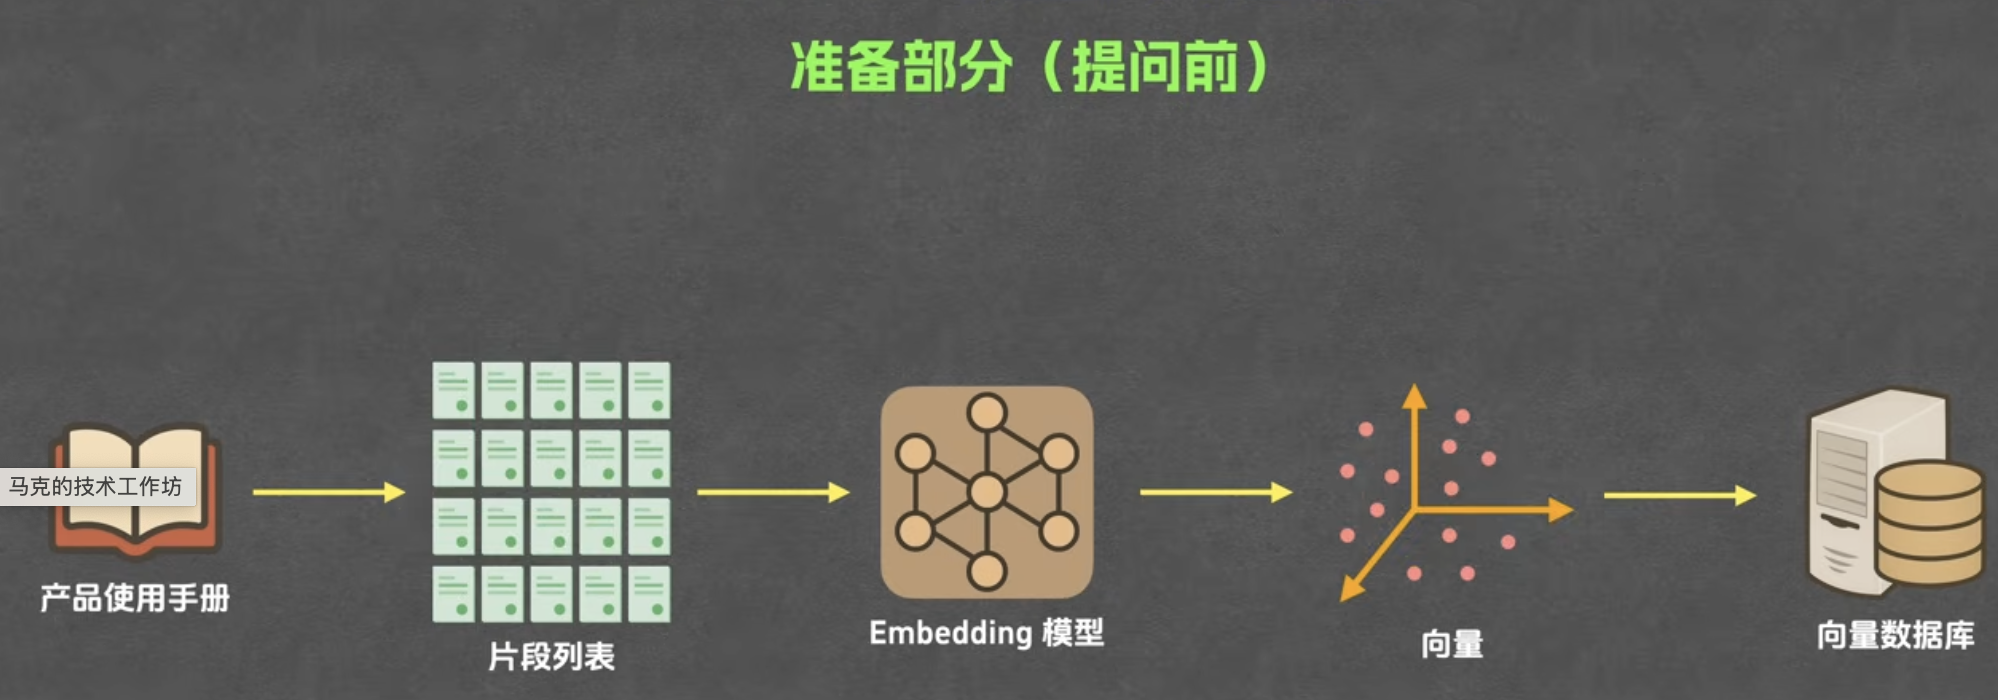

In [8]:
from IPython.display import Image, display

# 方式3: 显示图片并设置宽度
display(Image('2.png'))

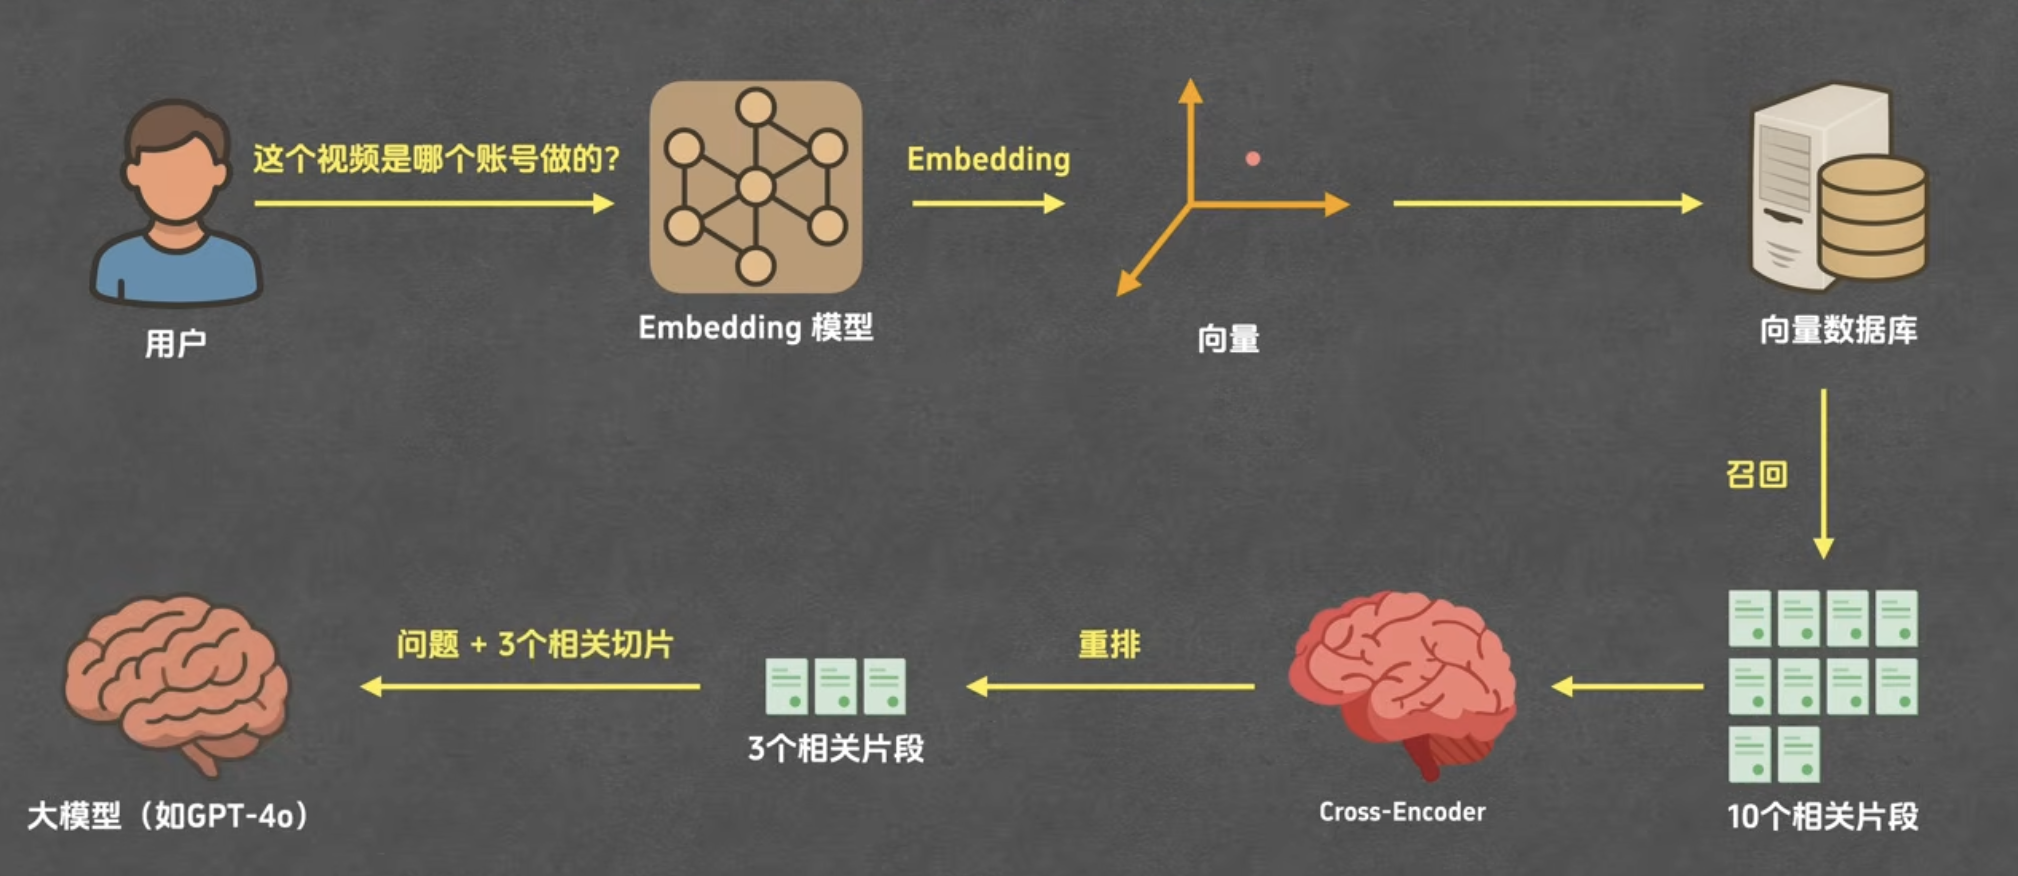

In [9]:
from IPython.display import Image, display

# 方式3: 显示图片并设置宽度
display(Image('1.png'))

In [ ]:
from typing import List

def split_into_chunks(doc_file: str) -> List[str]:
    with open(doc_file, 'r') as file:
        content = file.read()

    #return [chunk for chunk in content.split("\n\n")]
    return [chunk for chunk in content.split("本章完")]

chunks = split_into_chunks("doc.md")
#chunks = split_into_chunks("红楼梦.txt")
print(len(chunks))
for i, chunk in enumerate(chunks):
    print(f"[{i}] {chunk}\n")

In [21]:
from sentence_transformers import SentenceTransformer

embedding_model = SentenceTransformer("shibing624/text2vec-base-chinese")

def embed_chunk(chunk: str) -> List[float]:
    embedding = embedding_model.encode(chunk, normalize_embeddings=True)
    return embedding.tolist()


embedding = embed_chunk("测试内容")
print(len(embedding))
print(embedding)

768
[0.026805488392710686, 0.008382015861570835, 0.0003433709789533168, 0.007298998534679413, 0.0543331615626812, -0.05325589329004288, 0.0013655523071065545, -0.001318217720836401, -0.03671126067638397, 0.07188180834054947, -0.00727066257968545, -0.007053004112094641, 0.04253285378217697, -0.036752790212631226, -0.05475056916475296, -0.00959856528788805, 0.017105547711253166, 0.05915360152721405, -0.03335001692175865, 0.06237657368183136, -0.004888526163995266, -0.03453955054283142, -0.07407603412866592, 0.04422193020582199, 0.010516893118619919, -0.037077803164720535, -0.027029847726225853, 0.03830365464091301, 0.021282488480210304, -0.011811467818915844, -0.005408737808465958, 0.0026590318884700537, -0.02329857461154461, 0.05299091339111328, 0.005149443168193102, 0.02962418831884861, -0.030809666961431503, -0.017856106162071228, 0.04244604334235191, -0.007692313753068447, -0.010638090781867504, 0.03210863843560219, -0.06592468172311783, -0.012100924737751484, 0.006814600899815559, -

In [22]:
embeddings = [embed_chunk(chunk) for chunk in chunks]

print(len(embeddings))
print(embeddings[0])

121
[0.008166230283677578, -0.018120961263775826, 0.014717609621584415, 0.03394914045929909, 0.010085396468639374, -0.05970807373523712, 0.011818685568869114, 0.014575432054698467, 0.0027147913351655006, 0.01750272326171398, -0.0501168929040432, 0.007769758813083172, 0.019187984988093376, -0.026945719495415688, -0.062100477516651154, -0.017098339274525642, -0.03432055562734604, 0.03440620377659798, -0.04907217621803284, 0.015138941816985607, 0.025114119052886963, -0.004926524590700865, -0.07849319279193878, 0.04653281718492508, 0.012340987101197243, 0.0021987033542245626, 0.0469418503344059, 0.03043205477297306, -0.009677743539214134, 0.0052083944901824, 0.0232081301510334, 0.014405929483473301, -0.02625855803489685, 0.04654582217335701, -0.005156391300261021, 0.0267444159835577, 0.018785133957862854, -0.0018157388549298048, 0.02989792264997959, 0.029818838462233543, -0.0019494513981044292, 0.05621742084622383, -0.04296712204813957, -0.05523970350623131, -0.05030486360192299, 0.0328191

In [23]:
import chromadb

chromadb_client = chromadb.EphemeralClient()
chromadb_collection = chromadb_client.get_or_create_collection(name="default")

def save_embeddings(chunks: List[str], embeddings: List[List[float]]) -> None:
    for i, (chunk, embedding) in enumerate(zip(chunks, embeddings)):
        chromadb_collection.add(
            documents=[chunk],
            embeddings=[embedding],
            ids=[str(i)]
        )

save_embeddings(chunks, embeddings)

In [ ]:
def retrieve(query: str, top_k: int) -> List[str]:
    query_embedding = embed_chunk(query)
    results = chromadb_collection.query(
        query_embeddings=[query_embedding],
        n_results=top_k
    )
    return results['documents'][0]

query = "哆啦A梦使用的3个秘密道具分别是什么？"
#query = "贾宝玉的爸爸是谁"
retrieved_chunks = retrieve(query, 5)

for i, chunk in enumerate(retrieved_chunks):
    print(f"[{i}] {chunk}\n")
retrieved_chunks = [chunk.replace("\\", "") for chunk in retrieved_chunks]


[0] )
第110章 史太君寿终归地府 王凤姐力诎失人心
　　却说贾母坐起说道：“我到你们家已经六十多年了，从年轻的时候到老来，福也享尽了。自你们老爷起，儿子孙子也都算是好的了。就是宝玉呢，我疼了他一场，”说到那里，拿眼满地下瞅着，王夫人便推宝玉走到床前。贾母从被窝里伸出手来拉着宝玉，道：“我的儿，你要争气才好！”宝玉嘴里答应，心里一酸，那眼泪便要流下来，又不敢哭，只得站着。听贾母说道：“我想再见一个重孙子，我就安心了。我的兰儿在那里呢？”李纨也推贾兰上去。贾母放了宝玉，拉着贾兰道：“你母亲是要孝顺的。将来你成了人，也叫你母亲风光风光。凤丫头呢？”凤姐本来站在贾母旁边，赶忙走到跟前说：“在这里呢。”贾母道：“我的儿，你是太聪明了，将来修修福罢。我也没有修什么，不过心实吃亏。那些吃斋念佛的事我也不大干，就是旧年叫人写了些《金刚经》送送人，不知送完了没有？”凤姐道：“没有呢。”贾母道：“早该施舍完了才好。我们大老爷和珍儿是在外头乐了；最可恶的是史丫头没良心，怎么总不来瞧我！”鸳鸯等明知其故，都不言语。
　　贾母又瞧了一瞧宝钗，叹了口气，只见脸上发红。贾政知是回光返照，即忙进上参汤。贾母的牙关已经紧了，合了一回眼，又睁着满屋里瞧了一瞧。王夫人、宝钗上去，轻轻扶着，邢夫人、凤姐等便忙穿衣。地下婆子们已将床安设停当，铺了被褥。听见贾母喉间略一响动，脸变笑容，竟是去了。享年八十三岁。众婆子疾忙停床。
　　于是贾政等在外一边跪着，邢夫人等在内一边跪着，一齐举起哀来。外面家人各样预备齐全，只听里头信儿一传出来，从荣府大门起至内宅门，扇扇大开，一色净白纸糊了；孝棚高起，大门前的牌楼立时竖起。上下人等登时成服。贾政报了丁忧，礼部奏闻。主上深仁厚泽，念及世代功勋，又系元妃祖母，赏银一千两，谕礼部主祭。家人们各处报丧。众亲友虽知贾家势败，今见圣恩隆重，都来探丧。择了吉时成殓，停灵正寝。
　　贾赦不在家，贾政为长；宝玉、贾兰是亲孙，年纪又小，都应守灵。贾琏虽也是亲孙，带着贾蓉，尚可分派家人办事。虽请了些男女外亲来照应，内里邢、王二夫人、李纨、凤姐、宝钗等是应灵旁哭泣的；尤氏虽可照应，他自贾珍外出，依住荣府，一向总不上前，且又荣府的事不甚谙练；贾蓉的媳妇更不必说，惜春年小，虽在这里长的，他于家事全不知道。所以内里竟无一人支持，只有凤姐可以照管里头的事，况又贾琏在外作主，里外他二人，倒也相宜。

In [ ]:
# from sentence_transformers import CrossEncoder

# def rerank(query: str, retrieved_chunks: List[str], top_k: int) -> List[str]:
#     cross_encoder = CrossEncoder('cross-encoder/mmarco-mMiniLMv2-L12-H384-v1')
#     pairs = [(query, chunk) for chunk in retrieved_chunks]
#     scores = cross_encoder.predict(pairs)

#     scored_chunks = list(zip(retrieved_chunks, scores))
#     scored_chunks.sort(key=lambda x: x[1], reverse=True)

#     return [chunk for chunk, _ in scored_chunks][:top_k]

# reranked_chunks = rerank(query, retrieved_chunks, 3)

# for i, chunk in enumerate(reranked_chunks):
#     print(f"[{i}] {chunk}\n")

# reranked_chunks = [chunk.replace("\\", "") for chunk in reranked_chunks]

NameError: name 'query' is not defined

In [34]:
import requests

api_key  = "sk-asxlrjvdicxcggvoibqvmhixuqmrommiohqetgdtxowdzcfq"

print(api_key)
import requests

url = "https://api.siliconflow.cn/v1/chat/completions"

import openai
import json
def generate(query: str, chunks: List[str]) -> str:
    model="Qwen/Qwen3-8B"
    #print("api key ",api_key)
    print("model is ",model)
    # 修复 f-string 表达式中不能包含反斜杠的语法错误
    prompt = (
        "你是一位知识助手，请根据用户的问题和下列片段生成准确的回答。"
        f"用户问题: {query} 相关片段:{chr(10)+chr(10).join(chunks)}  请基于上述内容作答，不要编造信息。"
    )
   # prompt = f"""你是一位知识助手，请根据用户的问题和下列片段生成准确的回答。用户问题: {query} 相关片段:{"\n\n".join(chunks)}  请基于上述内容作答，不要编造信息。"""
    # 创建请求体字典，用于构建 API 请求参数
    payload = {
        "model": model,  # 指定要使用的模型名称（如 "Qwen/Qwen3-8B"）
        # 消息列表，包含对话历史
        "messages": [
            {
                "role": "user",  # 消息角色：用户
                "content": prompt  # 用户输入的内容（提示词）
            }
        ],
        # 是否使用流式输出，False 表示返回完整响应
        "stream": False,
        # 生成内容的最大 token 数量限制
        "max_tokens": 512,
        # 是否启用思考模式（推理链）
        "enable_thinking": False,
        # 思考模式的 token 预算（当前未启用）
        "thinking_budget": 4096,
        # 最小概率阈值，过滤掉累积概率低于 5% 的 token
        "min_p": 0.05,
        # 停止序列，遇到这些序列时停止生成（None 表示不设置）
        "stop": None,
        # 温度参数，控制输出的随机性（0.7 表示中等随机性）
        "temperature": 0.7,
        # 核采样参数，只考虑累积概率前 70% 的 token
        "top_p": 0.7,
        # Top-K 采样，只从概率最高的 50 个 token 中选择
        "top_k": 50,
        # 频率惩罚，降低重复 token 的概率（0.5 表示中等惩罚）
        "frequency_penalty": 0.5,
        # 生成多少个响应候选（1 表示只生成一个）
        "n": 1,
        # 响应格式为纯文本
        "response_format": {"type": "text"},
        # 函数调用工具配置（当前被注释，未启用）
        # "tools": [
        #     {
        #         "type": "function",  # 工具类型：函数
        #         "function": {  # 函数定义
        #             "description": "<string>",  # 函数描述
        #             "name": "<string>",  # 函数名称
        #             "parameters": {},  # 函数参数
        #             "strict": False  # 是否严格模式
        #         }
        #     }
        # ]
    }
    headers = {
        "Authorization": f"Bearer {api_key}",
        "Content-Type": "application/json"
    }
    response = requests.request("POST", url, json=payload, headers=headers)
    print(response.text,type(response.text))
    res_json = json.loads(response.text)
    #content = ""
    content = res_json["choices"][0]["message"]["content"]
    #print(content)
    return content


answer = generate(query, retrieved_chunks)
print(answer)

sk-asxlrjvdicxcggvoibqvmhixuqmrommiohqetgdtxowdzcfq
model is  Qwen/Qwen3-8B
{"id":"019bac7f8889510ba4deed669758a3e4","object":"chat.completion","created":1768125598,"model":"Qwen/Qwen3-8B","choices":[{"index":0,"message":{"role":"assistant","content":"贾宝玉的爸爸是贾政。"},"finish_reason":"stop"}],"usage":{"prompt_tokens":29676,"completion_tokens":8,"total_tokens":29684,"completion_tokens_details":{"reasoning_tokens":0}},"system_fingerprint":""} <class 'str'>
贾宝玉的爸爸是贾政。


# HomeWork 
